In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Setup

In [2]:
data = pd.read_csv("data.csv")

In [3]:
train = data.loc[:71423]
train.head(3)

,Unnamed: 0,date,time,power,workday
0,0,2022-01-01,0.00,0.0,0
1,1,2022-01-01,0.25,0.0,0
2,2,2022-01-01,0.50,0.0,0


In [4]:
test = data.loc[71424:]
test.head(3)

,Unnamed: 0,date,time,power,workday
71424,71424,2024-01-15,0.00,-1.367699e-07,0
71425,71425,2024-01-15,0.25,-1.367699e-07,0
71426,71426,2024-01-15,0.50,-1.367699e-07,0


In [5]:
def get_X_y(df, lookahead):
    power = df['power'].to_numpy()
    workday = df['workday'].to_numpy()
    time = df['time'].to_numpy()
    
    power_chunks = [power[i:i+lookahead] for i in range(0, len(power) - lookahead, lookahead)]
    workday = [workday[i] for i in range(0, len(power) - lookahead, lookahead)]
    time = [time[i] for i in range(0, len(power) - lookahead, lookahead)]
    
    y = [power[i:i+lookahead] for i in range(lookahead, len(power), lookahead)]

    X = pd.DataFrame(data={"power" : power_chunks, "workday" : workday, "time" : time})
    y = pd.DataFrame(data={"power" : y})

    X = X.reset_index()
    y = y.reset_index()

    return X, y

In [6]:
LOOKAHEAD = 16

X_trainval, y_trainval = get_X_y(train, LOOKAHEAD)
X_test, y_test = get_X_y(test, LOOKAHEAD)

In [7]:
data = pd.read_csv("data.csv")

In [8]:
train = data.loc[:71423]
train.tail(3)

,Unnamed: 0,date,time,power,workday
71421,71421,2024-01-14,23.25,-1.367699e-07,0
71422,71422,2024-01-14,23.50,-1.367699e-07,0
71423,71423,2024-01-14,23.75,-1.367699e-07,0


In [9]:
test = data.loc[71424:]
test.head(3)

,Unnamed: 0,date,time,power,workday
71424,71424,2024-01-15,0.00,-1.367699e-07,0
71425,71425,2024-01-15,0.25,-1.367699e-07,0
71426,71426,2024-01-15,0.50,-1.367699e-07,0


In [10]:
def get_X_y(df, lookahead):
    power = df['power'].to_numpy()
    workday = df['workday'].to_numpy()
    time = df['time'].to_numpy()
    
    power_chunks = [power[i:i+lookahead] for i in range(0, len(power) - lookahead, lookahead)]
    workday = [workday[i] for i in range(0, len(power) - lookahead, lookahead)]
    time = [time[i] for i in range(0, len(power) - lookahead, lookahead)]
    
    y = [power[i:i+lookahead] for i in range(lookahead, len(power), lookahead)]

    X = pd.DataFrame(data={"power" : power_chunks, "workday" : workday, "time" : time})
    y = pd.DataFrame(data={"power" : y})

    X = X.reset_index()
    y = y.reset_index()

    return X, y

In [11]:
LOOKAHEAD = 16

X_trainval, y_trainval = get_X_y(train, LOOKAHEAD)
X_test, y_test = get_X_y(test, LOOKAHEAD)

In [12]:
lst = []
for index, row in X_trainval.iterrows():
    time_ohe = [0, 0, 0, 0, 0]
    if row['time'] < 20:
        time_ohe[int(row['time'] / 4)] = 1
    lst.append(list(row['power']) + [row['workday']] + time_ohe)

X_trainval = np.array(lst)

lst = []
for index, row in y_trainval.iterrows():
    lst.append(list(row['power']))

y_trainval = np.array(lst)

lst = []
for index, row in X_test.iterrows():
    time_ohe = [0, 0, 0, 0, 0]
    if row['time'] < 20:
        time_ohe[int(row['time'] / 4)] = 1
    lst.append(list(row['power']) + [row['workday']] + time_ohe)

X_test = np.array(lst)

lst = []
for index, row in y_test.iterrows():
    lst.append(list(row['power']))

y_test = np.array(lst)

In [44]:
import torch
import torch.nn as nn

class AsymmetricRMSELoss(nn.Module):
    def __init__(self, alpha):
        super(AsymmetricRMSELoss, self).__init__()
        self.multiplier = alpha**2

    def forward(self, input, target):
        mse_loss = nn.functional.mse_loss(input, target, reduction='none')
        residual = input - target
        mask = residual < 0  # mask for underpredictions
        loss = torch.sqrt(torch.mean((mse_loss + (self.multiplier - 1) * mask.float()) * mse_loss))
        return loss

# Example usage:
criterion = AsymmetricRMSELoss(alpha=2.0)

# Hyperparam Tuning

In [45]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from itertools import product


# Set random seed for PyTorch
torch.manual_seed(42)

# Set random seed for NumPy
np.random.seed(42)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert data to PyTorch tensors
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Define the neural network architecture
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_hidden_layers, activation):
        super(FFNN, self).__init__()
        self.hidden_layers = nn.ModuleList([nn.Linear(input_size, hidden_size)])
        self.hidden_layers.extend([nn.Linear(hidden_size, hidden_size) for _ in range(num_hidden_layers-1)])
        self.activation = activation
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = torch.relu(self.fc_out(x))
        return x

In [14]:
hidden_sizes = [32, 64, 128]
num_hidden_layers_list = [1, 2]
activations = [nn.ReLU(), nn.Sigmoid()]
learning_rates = [0.01, 0.001]
epochs = 500
batch_sizes = [32, 64]

# Perform grid search
best_model = None
best_rmse = float('inf')
best_learning_rate = None

for hidden_size, num_hidden_layers, activation, learning_rate in product(hidden_sizes, num_hidden_layers_list, activations, learning_rates):
    model = FFNN(input_size=X_train.shape[1], hidden_size=hidden_size, output_size=y_train.shape[1], num_hidden_layers=num_hidden_layers, activation=activation)
    criterion = AsymmetricRMSELoss(2)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        # Train the model
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train_tensor)
        loss = criterion(y_pred.squeeze(), y_train_tensor)
        loss.backward()
        optimizer.step()
    
    # Evaluate the model
    model.eval()
    y_pred_val = model(X_val_tensor).detach().numpy().squeeze()
    rmse = criterion.forward(torch.tensor(y_val, dtype=torch.float32), torch.tensor(y_pred_val, dtype=torch.float32)).item()

    # Update best model
    if rmse < best_rmse:
        best_learning_rate = learning_rate
        best_rmse = rmse
        best_model = model

print("Best RMSE:", best_rmse)

Best RMSE: 7.904109477996826


In [15]:
best_model

FFNN(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=64, bias=True)
  )
  (activation): ReLU()
  (fc_out): Linear(in_features=64, out_features=16, bias=True)
)

In [16]:
best_learning_rate

0.01

# Final Model

In [46]:
model = FFNN(input_size=X_train.shape[1], hidden_size=64, output_size=y_train.shape[1], num_hidden_layers=2, activation=nn.ReLU())
criterion = AsymmetricRMSELoss(alpha=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10000):
    # Train the model
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred.squeeze(), y_train_tensor)
    loss.backward()
    optimizer.step()

y_pred_test = model(X_test_tensor).detach().numpy().squeeze()

# Evaluate the model
model.eval()
y_pred_test = model(X_test_tensor).detach().numpy().squeeze()
rmse = np.sqrt(criterion.forward(y_test_tensor, torch.tensor(y_pred_test, dtype=torch.float32))).item()

In [47]:
rmse

9.063284873962402

In [48]:
real = y_test.flatten()
forecast = y_pred_test.flatten()

1 - sum(forecast >= real) / len(real)

0.35749385749385754

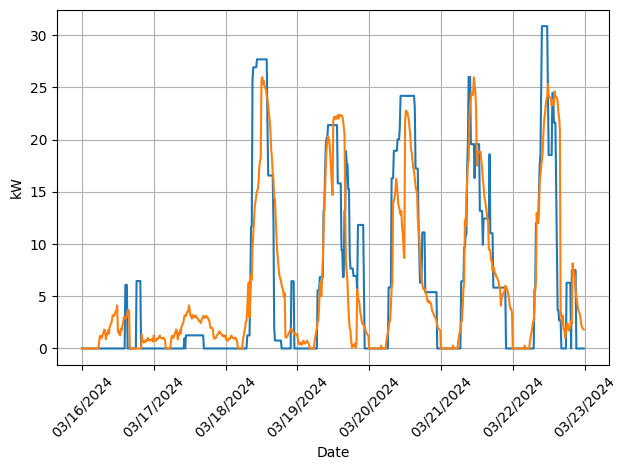

In [49]:
dates = pd.date_range(start='2024-03-16', periods=672, freq='15T')

plt.plot(dates, real[-96*7:])
plt.plot(dates, forecast[-96*7:])

# Set x-axis labels format
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d/%Y'))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('kW')
plt.grid(True)
plt.tight_layout()
plt.show()